# Surface Scores

In [5]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

In [1]:
import numpy as np

def compute_circle_intersections(center, radius, other_centers, other_radii):
    other_centers = other_centers - center
    c = 0.5 * (radius**2 - other_radii**2 + (other_centers**2).sum(axis=-1))
    A = 2 * other_centers
    b = c / np.linalg.norm(A, axis=-1)
    A_normalized = A / np.linalg.norm(A, axis=-1, keepdims=True)
    discriminant = b**2 - np.sum(A_normalized**2, axis=-1) + 1e-8
    valid = discriminant >= 0
    t1 = b + np.sqrt(discriminant)
    t2 = b - np.sqrt(discriminant)
    intersections = []
    for i in range(other_centers.shape[0]):
        if valid[i]:
            point1 = center + t1[i] * A_normalized[i]
            point2 = center + t2[i] * A_normalized[i]
            intersections.append((point1, point2))
    return intersections

In [ ]:
import numpy as np
# chatgpt
def circle_circle_intersection_angles(circles_a, circles_b, *, eps=1e-12):
    """
    Compute intersection-point angles for all pairs between two circle lists.

    Parameters
    ----------
    circles_a : (N, 3) array_like
        Circle parameters (x, y, r) for set A.
    circles_b : (M, 3) array_like
        Circle parameters (x, y, r) for set B.
    eps : float
        Small tolerance for numerical stability and validity checks.

    Returns
    -------
    angles_a : (N, M, 2) ndarray
        Intersection angles (radians) on circles in set A for the two intersection points.
        Ordering corresponds to the +/- branch of the standard formula. NaN where invalid.
    angles_b : (N, M, 2) ndarray
        Intersection angles (radians) on circles in set B for the two intersection points.
        NaN where invalid.
    valid : (N, M) ndarray of bool
        True where circles intersect (including tangency) and are not coincident.
        Coincident circles (infinite intersections) are marked False.

    Notes
    -----
    - Valid includes both 2-intersection and 1-intersection (tangent) cases.
    - Coincident circles (same center and same radius) are not treated as valid because
      the intersection set is infinite (angles undefined).
    """
    A = np.asarray(circles_a, dtype=float)
    B = np.asarray(circles_b, dtype=float)
    if A.ndim != 2 or A.shape[1] != 3:
        raise ValueError("circles_a must have shape (N, 3) as (x, y, r). Got shape {}".format(A.shape))
    if B.ndim != 2 or B.shape[1] != 3:
        raise ValueError("circles_b must have shape (M, 3) as (x, y, r). Got shape {}".format(B.shape))

    ax, ay, ar = A[:, 0], A[:, 1], A[:, 2]
    bx, by, br = B[:, 0], B[:, 1], B[:, 2]

    # Broadcast pairwise deltas: shape (N, M)
    dx = bx[None, :] - ax[:, None]
    dy = by[None, :] - ay[:, None]
    d2 = dx * dx + dy * dy
    d = np.sqrt(d2)

    # Validity conditions:
    # - not coincident (d ~ 0 and r equal)
    # - intersects or tangent: |r0-r1| <= d <= r0+r1
    rsum = ar[:, None] + br[None, :]
    rdiff = np.abs(ar[:, None] - br[None, :])

    coincident = (d <= eps) & (np.abs(ar[:, None] - br[None, :]) <= eps)
    separate_or_contained = (d > rsum + eps) | (d < rdiff - eps)

    valid = (~coincident) & (~separate_or_contained) & (d > eps)

    # Safe distance for divisions (avoid /0)
    d_safe = np.where(d > eps, d, 1.0)

    # Standard circle-circle intersection math
    a = (ar[:, None] ** 2 - br[None, :] ** 2 + d_safe ** 2) / (2.0 * d_safe)
    h2 = ar[:, None] ** 2 - a ** 2

    # Clamp h2 to 0 for near-tangent numerical negatives
    h2 = np.where(h2 < 0.0, np.maximum(h2, 0.0), h2)
    h = np.sqrt(h2)

    # Point along the center-center line (base point)
    x2 = ax[:, None] + a * dx / d_safe
    y2 = ay[:, None] + a * dy / d_safe

    # Offset perpendicular to center-center line
    rx = -dy / d_safe
    ry =  dx / d_safe

    # Two intersection points for each pair (N, M)
    x3p = x2 + h * rx
    y3p = y2 + h * ry
    x3m = x2 - h * rx
    y3m = y2 - h * ry

    # Angles on circle A
    ang_a_p = np.arctan2(y3p - ay[:, None], x3p - ax[:, None])
    ang_a_m = np.arctan2(y3m - ay[:, None], x3m - ax[:, None])

    # Angles on circle B
    ang_b_p = np.arctan2(y3p - by[None, :], x3p - bx[None, :])
    ang_b_m = np.arctan2(y3m - by[None, :], x3m - bx[None, :])

    # Pack and mask invalids with NaN
    angles_a = np.stack([ang_a_p, ang_a_m], axis=-1)
    angles_b = np.stack([ang_b_p, ang_b_m], axis=-1)

    angles_a = np.where(valid[..., None], angles_a, np.nan)
    angles_b = np.where(valid[..., None], angles_b, np.nan)

    return angles_a, angles_b, valid


In [6]:
import json
with open("../instances_data/instances_connected_room.json") as f:
    data = json.load(f)

In [9]:
from ael.problem import Problem
problem = Problem.from_json(data[0])

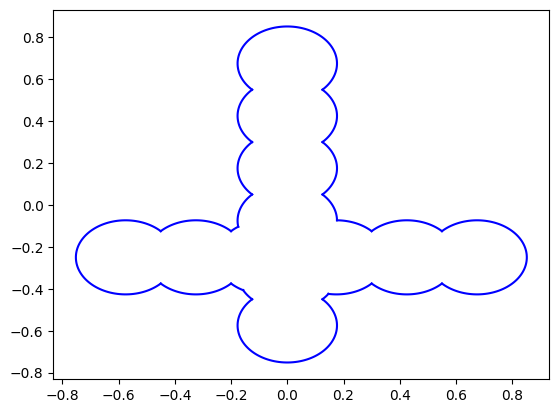

In [43]:
# Simplify the obstacles.
obstacle_circles = np.array(
    [
        [
            problem.obstacle_positions[i][0],
            problem.obstacle_positions[i][1],
            problem.obstacle_radii[i],
        ]
        for i in range(problem.num_obstacles)
    ]
)

int_a, int_b, valid = circle_circle_intersection_angles(
    obstacle_circles, obstacle_circles
)

# compute subdivisions
subdivisions = [
    sorted(
        set(
            [int_a[i][j][0] for j in range(len(int_a)) if valid[i][j]]
            + [int_a[i][j][1] for j in range(len(int_a)) if valid[i][j]]
        )
    )
    for i in range(len(int_a))
]

new_pairs = []
for i in range(len(subdivisions)):
    for ta, tb in zip(
        subdivisions[i], subdivisions[i][1:] + [subdivisions[i][0] + 2 * np.pi]
    ):
        mid_angle = 0.5 * (ta + tb)
        mid_x = obstacle_circles[i][0] + obstacle_circles[i][2] * np.cos(mid_angle)
        mid_y = obstacle_circles[i][1] + obstacle_circles[i][2] * np.sin(mid_angle)

        # Check if the midpoint is inside any other obstacle
        inside_other = False
        for j in range(len(obstacle_circles)):
            if i == j:
                continue
            dist = np.sqrt(
                (mid_x - obstacle_circles[j][0]) ** 2
                + (mid_y - obstacle_circles[j][1]) ** 2
            )
            if dist < obstacle_circles[j][2]:
                inside_other = True
                break

        if not inside_other:
            new_pairs.append((i, ta, tb))

# plot the arcs formed by these pairs

import matplotlib.pyplot as plt

for i, ta, tb in new_pairs:
    circle = obstacle_circles[i]
    theta = np.linspace(ta, tb, 100)
    x = circle[0] + circle[2] * np.cos(theta)
    y = circle[1] + circle[2] * np.sin(theta)
    plt.plot(x, y, "b-")

plt.show()


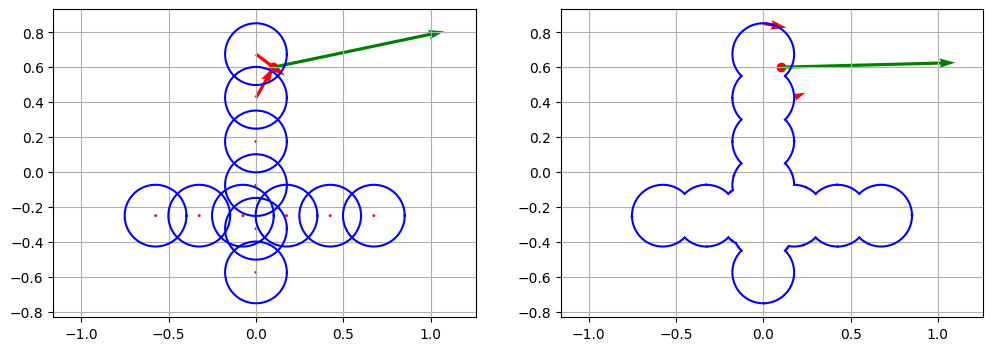

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

x = 0.1
y = 0.6
sigma = 0.1
overall_score_x = 0.0
overall_score_y = 0.0

plt.subplot(1, 2, 1)
plt.scatter([x], [y], color="red", label="Point of interest")

for i in range(len(obstacle_circles)):
    circle = obstacle_circles[i]
    theta = np.linspace(0, 2 * np.pi, 100)
    delta_x2 = circle[2] * np.cos(theta)
    delta_y2 = circle[2] * np.sin(theta)
    x2 = circle[0] + delta_x2
    y2 = circle[1] + delta_y2

    # draw score contribution from this arc
    dxy2 = np.sqrt((x2[1:] - x2[:-1]) ** 2 + (y2[1:] - y2[:-1]) ** 2)
    pdf2 = np.exp(-0.5 * ((x2 - x) ** 2 + (y2 - y) ** 2) / sigma**2)
    vec_x = np.sum(np.cos(theta[:-1]) * pdf2[:-1] * dxy2)
    vec_y = np.sum(np.sin(theta[:-1]) * pdf2[:-1] * dxy2)

    overall_score_x += vec_x
    overall_score_y += vec_y

    plt.quiver(
        circle[0],  # use the midpoint of the arc for the vector position
        circle[1],
        vec_x,
        vec_y,
        angles="xy",
        scale_units="xy",
        scale=1,
        color="red",
    )

    plt.plot(x2, y2, "b-")

mag = np.sqrt(overall_score_x**2 + overall_score_y**2)
plt.quiver(
    x,
    y,
    # overall_score_x,
    # overall_score_y,
    overall_score_x / mag,
    overall_score_y / mag,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label="Overall score vector",
)

plt.grid()
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter([x], [y], color="red", label="Point of interest")
overall_score_x = 0.0
overall_score_y = 0.0

for i, ta, tb in new_pairs:
    circle = obstacle_circles[i]
    theta = np.linspace(ta, tb, 100)
    delta_x2 = circle[2] * np.cos(theta)
    delta_y2 = circle[2] * np.sin(theta)
    x2 = circle[0] + delta_x2
    y2 = circle[1] + delta_y2

    # draw score contribution from this arc
    dxy2 = np.sqrt((x2[1:] - x2[:-1]) ** 2 + (y2[1:] - y2[:-1]) ** 2)
    pdf2 = np.exp(-0.5 * ((x2 - x) ** 2 + (y2 - y) ** 2) / sigma**2)
    vec_x = np.sum(np.cos(theta[:-1]) * pdf2[:-1] * dxy2)
    vec_y = np.sum(np.sin(theta[:-1]) * pdf2[:-1] * dxy2)

    overall_score_x += vec_x
    overall_score_y += vec_y

    plt.quiver(
        x2[len(theta) // 2],  # use the midpoint of the arc for the vector position
        y2[len(theta) // 2],
        vec_x,
        vec_y,
        angles="xy",
        scale_units="xy",
        scale=1,
        color="red",
    )

    plt.plot(x2, y2, "b-")

mag = np.sqrt(overall_score_x**2 + overall_score_y**2)

plt.quiver(
    x,
    y,
    overall_score_x / mag,
    overall_score_y / mag,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label="Overall score vector",
)
plt.axis("equal")
plt.grid()

plt.show()

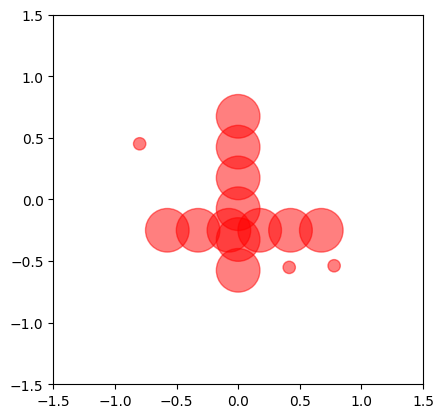

In [15]:
trajectory = np.linspace(
    problem.agent_start_positions,
    problem.agent_end_positions,
    num=problem.num_timesteps,
)

# compute feasible region for first agent at timestep 0
other_circles = np.array(
    [
        [
            problem.obstacle_positions[i][0],
            problem.obstacle_positions[i][1],
            problem.obstacle_radii[i],
        ]
        for i in range(problem.num_obstacles)
    ]
    + [
        [trajectory[0, 1, 0], trajectory[0, 1, 1], problem.agent_radii[1]],
        [trajectory[0, 2, 0], trajectory[0, 2, 1], problem.agent_radii[2]],
    ]
    + [
        [trajectory[1, 0, 0], trajectory[1, 0, 1], problem.agent_max_speeds[0]],
    ]
)

# Plot the 'other circles'.

import matplotlib.pyplot as plt


fig, ax = plt.subplots()
for circle in other_circles:
    circle_patch = plt.Circle((circle[0], circle[1]), circle[2], color="red", alpha=0.5)
    ax.add_patch(circle_patch)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

# Compute intersections between this agent and the other circles.

angles_a, angles_b, valid = circle_circle_intersection_angles(
    np.array(
        [
            [
                trajectory[0, 0, 0],
                trajectory[0, 0, 1],
                problem.agent_radii[0],
            ]
        ]
    ),
    other_circles,
)
